# Benchmark: PXD014777 HeLa, Yeast and Ecoli dataset

This notebook contains code to benchmark the PIPP model on [PXD014777 dataset](https://proteomecentral.proteomexchange.org/cgi/GetDataset?ID=PXD014777) - Tenzer.nomatching_MaxQuant.txt.zip and HeLa10replicates2h-1.0.10.4_MaxQuant.txt.zip. We'll use the following txt files from the datasets:

HeLa10replicates2h-1.0.10.4_MaxQuant.txt.zip:
- allPeptides.txt: All the peptides with MS-1 data for HeLa
- evidence.txt: A subset of the peptides in allPeptides.txt, which contains both MS-1 and MS-2 data


Tenzer.nomatching_MaxQuant.txt.zip:
- evidence.txt: Contains both MS-1 and MS-2 data for the 3 species: Ecoli, Yeast and HeLa

We'll use PIPP to compute the embeddings of each MS-1 datapoint. Followed by peptide identity propagation using the MS1/MS2 data as the support data. Since multiple HeLa are available in the MS2 dataset, and only HeLU in the MS1 dataset, we'll also compute false discovery rates.

Let's start with the imports.

In [2]:
%%capture

%matplotlib inline

%load_ext autoreload
%autoreload 2

from collections import defaultdict
import re
import os

import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objs as go
import multiprocessing

import pipp
import pipp.utils

np.random.seed(0)

Let's define the paths to the data and the pretrained model.

In [3]:
HELA_PEPTIDES_PATH = "../../data/HeLa10replicates/txt/allPeptides.txt"
HELA_EVIDENCE_PATH = "../../data/HeLa10replicates/txt/evidence.txt"
HELA_EVIDENCE_MAPPED_PATH = "../../data/HeLa10replicates/txt/evidence_mapped.txt" # @NOTE: gets auto-generated if file doesn't exist

SPECIES_EVIDENCE_PATH = "../../data/tenzer_nomatching/txt/evidence.txt"

PRETRAINED_MODEL_PATH = "../../data/PXD019086_PXD010012_combined_evidence_90Kto20Ksplit_5query_1shot_fullmodel_featuresScaled_allPeptidesTxtFeatures_modSeqSpecies_hidden64_latent10_maxEpoch300_164trainways_xlatent_conditionalEmbedding.pth"

## Data Preparation

Let's load and clean the data.

In [4]:
ms1_hela_raw_data = pd.read_csv(HELA_PEPTIDES_PATH, sep='\t', header=0)
ms1_hela_raw_data['Dataset'] = 'HeLa'

In [5]:
ms1_hela_raw_data

,Raw file,Charge,m/z,Mass,Resolution,Number of data points,Number of frames,Number of isotopic peaks,Isotope correlation,Mass fractional part,...,Max frame index,Ion mobility index,Ion mobility index length,Ion mobility index length (FWHM),Intensity,Intensities,Number of pasef MS/MS,Pasef MS/MS IDs,MS/MS scan number,Dataset
0,20190122_HeLa_QC_Slot1-47_1_3219,1,338.33994,337.33266,24030.404323,9653,31,2,0.998584,0.332660,...,7008,198,63,18,65559.0,NaN,0,NaN,NaN,HeLa
1,20190122_HeLa_QC_Slot1-47_1_3219,1,310.17551,309.16823,24543.249420,767,16,2,0.997070,0.168230,...,5770,381,9,9,9176.1,NaN,0,NaN,NaN,HeLa
2,20190122_HeLa_QC_Slot1-47_1_3219,1,310.17568,309.16840,24202.340207,9120,46,2,0.999028,0.168403,...,5782,399,75,24,85099.0,NaN,0,NaN,NaN,HeLa
3,20190122_HeLa_QC_Slot1-47_1_3219,1,310.17564,309.16837,24121.266571,2617,19,2,0.997485,0.168368,...,5663,402,54,24,43377.0,NaN,0,NaN,NaN,HeLa
4,20190122_HeLa_QC_Slot1-47_1_3219,1,310.17564,309.16836,24185.426430,8433,25,2,0.999795,0.168364,...,5703,393,60,27,113520.0,NaN,0,NaN,NaN,HeLa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4101550,20190122_HeLa_QC_Slot1-47_1_3228,3,401.51001,1201.50820,25262.295341,93,4,2,0.979264,0.508215,...,1839,957,9,9,3099.1,NaN,0,NaN,NaN,HeLa
4101551,20190122_HeLa_QC_Slot1-47_1_3228,3,363.15319,1086.43770,25378.536155,476,7,2,0.982066,0.437736,...,1164,954,27,15,12634.0,NaN,6,41008;41018;41029;41040;41052;41062,15369.0,HeLa
4101552,20190122_HeLa_QC_Slot1-47_1_3228,3,348.16600,1041.47620,24875.051340,486,9,2,0.964573,0.476174,...,1093,960,18,12,8744.4,NaN,9,35325;35333;35340;35348;35356;35366;35376;3538...,12463.0,HeLa
4101553,20190122_HeLa_QC_Slot1-47_1_3228,3,338.17870,1011.51430,25441.194149,542,9,2,0.950810,0.514278,...,1093,960,21,15,9544.3,NaN,5,35407;35417;35426;35434;35442,10767.0,HeLa


In [6]:
if not os.path.isfile(HELA_EVIDENCE_MAPPED_PATH):
    ms2_hela_raw_data = pd.read_csv(HELA_EVIDENCE_PATH, sep='\t', header=0, low_memory=False)
    ms2_hela_raw_data = pipp.utils.link_MSMS_to_MS(ms2_hela_raw_data, ms1_hela_raw_data, verbose=True)
    ms2_hela_raw_data.to_csv(HELA_EVIDENCE_MAPPED_PATH, sep='\t', index=True)

In [7]:
ms2_hela_raw_data = pd.read_csv(HELA_EVIDENCE_MAPPED_PATH, sep='\t', header=0, low_memory=False)
ms2_hela_raw_data['Dataset'] = 'HeLa'

In [8]:
ms2_species_raw_data = pd.read_csv(SPECIES_EVIDENCE_PATH, sep='\t', header=0, low_memory=False)
ms2_species_raw_data['Dataset'] = 'Multi-species'

Let's look at the dimensions of the data.

In [9]:
print('HeLa MS1 data shape:        {}'.format(ms1_hela_raw_data.shape))
print('HeLa MS1+MS2 data shape:    {}'.format(ms2_hela_raw_data.shape))
print('species MS1+MS2 data shape: {}'.format(ms2_species_raw_data.shape))

HeLa MS1 data shape:        (4101555, 25)
HeLa MS1+MS2 data shape:    (634466, 72)
species MS1+MS2 data shape: (219367, 71)


### MS1 data preprocessing

Let's look at the features available in the MS1 data:

In [10]:
ms1_hela_raw_data.columns.unique()

Index(['Raw file', 'Charge', 'm/z', 'Mass', 'Resolution',
       'Number of data points', 'Number of frames', 'Number of isotopic peaks',
       'Isotope correlation', 'Mass fractional part', 'Mass deficit',
       'Retention time', 'Retention length', 'Retention length (FWHM)',
       'Min frame index', 'Max frame index', 'Ion mobility index',
       'Ion mobility index length', 'Ion mobility index length (FWHM)',
       'Intensity', 'Intensities', 'Number of pasef MS/MS', 'Pasef MS/MS IDs',
       'MS/MS scan number', 'Dataset'],
      dtype='object')

Let's filter out low quality peptides.

In [11]:
# filter out low quality peptides
ms1_hela_data = ms1_hela_raw_data.loc[(ms1_hela_raw_data['Charge'] != 1) & (ms1_hela_raw_data['Intensity'] > 0)]

In [12]:
ms1_hela_raw_peptides_per_run = [np.sum(ms1_hela_raw_data['Raw file'] == run) for run in ms1_hela_raw_data['Raw file'].unique()]
ms1_hela_peptides_per_run = [np.sum(ms1_hela_data['Raw file'] == run) for run in ms1_hela_data['Raw file'].unique()]

Text(0, 0.5, 'Number of peptides')

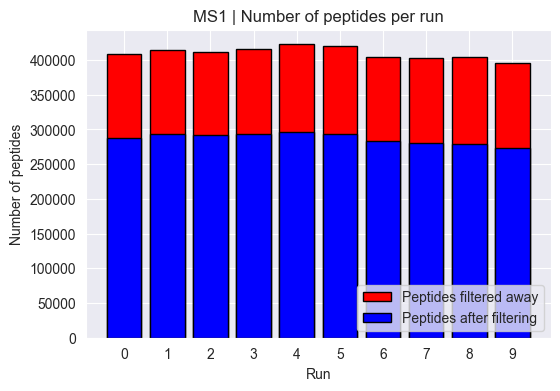

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(range(len(ms1_hela_raw_peptides_per_run)), ms1_hela_raw_peptides_per_run, color='red', edgecolor='black')
ax.bar(range(len(ms1_hela_peptides_per_run)), ms1_hela_peptides_per_run, color='blue', edgecolor='black')
ax.legend(['Peptides filtered away', 'Peptides after filtering'], loc='lower right')

ax.grid(True)
ax.set_axisbelow(True)
ax.set_xticks(np.arange(0, len(ms1_hela_raw_peptides_per_run), 1))
ax.set_title("MS1 | Number of peptides per run")
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [14]:
print(f"After filtering | MS1 data points: {ms1_hela_data.shape[0]} ({ms1_hela_data.shape[0] / ms1_hela_raw_data.shape[0] * 100:.2f}%)")

After filtering | MS1 data points: 2871496 (70.01%)


### MS2 (MSMS) data preprocessing

#### HeLa - MS2 data

Let's look at the features available in the MS2 data:

In [15]:
ms2_hela_raw_data.columns.unique()

Index(['Unnamed: 0', 'Sequence', 'Length', 'Modifications',
       'Modified sequence', 'Oxidation (M) Probabilities',
       'Oxidation (M) Score Diffs', 'Acetyl (Protein N-term)', 'Oxidation (M)',
       'Missed cleavages', 'Proteins', 'Leading proteins',
       'Leading razor protein', 'Gene names', 'Protein names', 'Type',
       'Raw file', 'Experiment', 'MS/MS m/z', 'Charge', 'm/z', 'Mass',
       'Resolution', 'Uncalibrated - Calibrated m/z [ppm]',
       'Uncalibrated - Calibrated m/z [Da]', 'Mass error [ppm]',
       'Mass error [Da]', 'Uncalibrated mass error [ppm]',
       'Uncalibrated mass error [Da]', 'Max intensity m/z 0', 'Retention time',
       'Retention length', 'Calibrated retention time',
       'Calibrated retention time start', 'Calibrated retention time finish',
       'Retention time calibration', 'Ion mobility index',
       'Ion mobility length', '1/K0', '1/K0 length', 'Calibrated 1/K0', 'CCS',
       'CCS length', 'Match time difference', 'Match m/z differe

Let's filter out low quality peptides.

In [16]:
# filter out low quality peptides
ms2_hela_data = ms2_hela_raw_data.loc[(ms2_hela_raw_data['Charge'] != 1) & (ms2_hela_raw_data['Intensity'] > 0)]

# keep the most intense peptides
ms2_hela_data = ms2_hela_data.loc[ms2_hela_data.groupby(['Modified sequence', 'Charge', 'Raw file'])['Intensity'].idxmax()]

# remove contaminants
ms2_hela_data = ms2_hela_data.loc[[(not bool(re.search('CON__|REV__', i))) for i in ms2_hela_data['Leading razor protein'].tolist()]]

# define identifier for each peptide
ms2_hela_data['PrecursorID'] = ms2_hela_data['Modified sequence'].astype(str).str.cat(ms2_hela_data['Charge'].astype(str), sep='')

In [17]:
ms2_hela_raw_peptides_per_run = [np.sum(ms2_hela_raw_data['Raw file'] == run) for run in ms2_hela_raw_data['Raw file'].unique()]
ms2_hela_peptides_per_run = [np.sum(ms2_hela_data['Raw file'] == run) for run in ms2_hela_data['Raw file'].unique()]

Text(0, 0.5, 'Number of peptides')

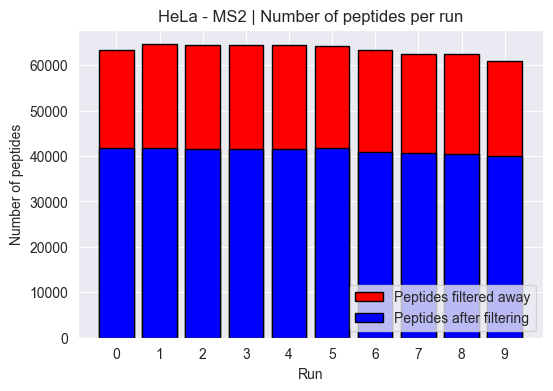

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(range(len(ms2_hela_raw_peptides_per_run)), ms2_hela_raw_peptides_per_run, color='red', edgecolor='black')
ax.bar(range(len(ms2_hela_peptides_per_run)), ms2_hela_peptides_per_run, color='blue', edgecolor='black')
ax.legend(['Peptides filtered away', 'Peptides after filtering'], loc='lower right')

ax.grid(True)
ax.set_axisbelow(True)
ax.set_title("HeLa - MS2 | Number of peptides per run")
ax.set_xticks(np.arange(0, len(ms2_hela_raw_peptides_per_run), 1))
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [19]:
print(f"After filtering | MS2 data points: {ms2_hela_data.shape[0]} ({ms2_hela_data.shape[0] / ms2_hela_raw_data.shape[0] * 100:.2f}%)")

After filtering | MS2 data points: 411838 (64.91%)


Let's see how many runs a peptide is present in.

In [20]:
peptide_abundances = ms2_hela_data['PrecursorID'].value_counts()

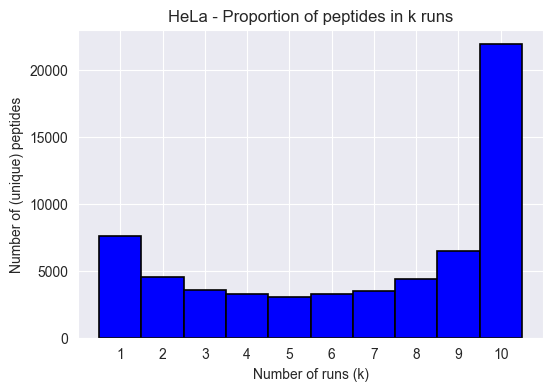

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(peptide_abundances, bins=range(1, np.max(peptide_abundances)+2), color='blue', edgecolor='black', linewidth=1.2, align='left')
ax.set_xticks(range(1, np.max(peptide_abundances)+1))
ax.set_title('HeLa - Proportion of peptides in k runs')
ax.set_xlabel('Number of runs (k)')
ax.set_ylabel('Number of (unique) peptides')
ax.grid(True)
ax.set_axisbelow(True)

Let's add a column with species.

In [22]:
ms2_hela_data['Species'] = 'HeLa'

#### Ecoli, Yeast and HeLa - MS2 data

Let's look at the features available in the MS2 data:

In [23]:
ms2_species_raw_data.columns.unique()

Index(['Sequence', 'Length', 'Modifications', 'Modified sequence',
       'Oxidation (M) Probabilities', 'Oxidation (M) Score Diffs',
       'Acetyl (Protein N-term)', 'Oxidation (M)', 'Missed cleavages',
       'Proteins', 'Leading proteins', 'Leading razor protein', 'Gene names',
       'Protein names', 'Type', 'Raw file', 'Experiment', 'MS/MS m/z',
       'Charge', 'm/z', 'Mass', 'Resolution',
       'Uncalibrated - Calibrated m/z [ppm]',
       'Uncalibrated - Calibrated m/z [Da]', 'Mass error [ppm]',
       'Mass error [Da]', 'Uncalibrated mass error [ppm]',
       'Uncalibrated mass error [Da]', 'Max intensity m/z 0', 'Retention time',
       'Retention length', 'Calibrated retention time',
       'Calibrated retention time start', 'Calibrated retention time finish',
       'Retention time calibration', 'Ion mobility index',
       'Ion mobility length', '1/K0', '1/K0 length', 'Calibrated 1/K0', 'CCS',
       'CCS length', 'Match time difference', 'Match m/z difference',
       '

Let's filter out low quality peptides.

In [24]:
# filter out low quality peptides
ms2_species_data = ms2_species_raw_data.loc[(ms2_species_raw_data['Charge'] != 1) & (ms2_species_raw_data['Intensity'] > 0)]

# keep the most intense peptides
ms2_species_data = ms2_species_data.loc[ms2_species_data.groupby(['Modified sequence', 'Charge', 'Raw file'])['Intensity'].idxmax()]

# remove contaminants
ms2_species_data = ms2_species_data.loc[[(not bool(re.search('CON__|REV__', i))) for i in ms2_species_data['Leading razor protein'].tolist()]]

# define identifier for each peptide
ms2_species_data['PrecursorID'] = ms2_species_data['Modified sequence'].astype(str).str.cat(ms2_species_data['Charge'].astype(str), sep='')

In [25]:
ms2_species_raw_peptides_per_run = [np.sum(ms2_species_raw_data['Raw file'] == run) for run in ms2_species_raw_data['Raw file'].unique()]
ms2_species_peptides_per_run = [np.sum(ms2_species_data['Raw file'] == run) for run in ms2_species_data['Raw file'].unique()]

Text(0, 0.5, 'Number of peptides')

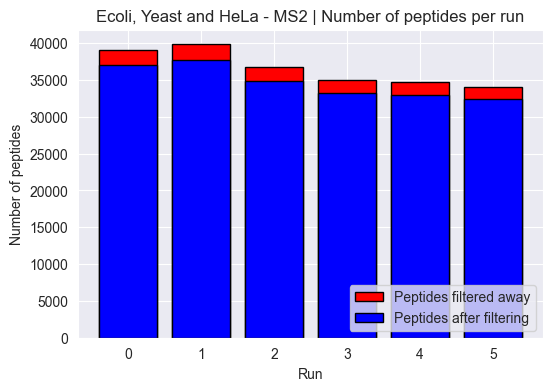

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(range(len(ms2_species_raw_peptides_per_run)), ms2_species_raw_peptides_per_run, color='red', edgecolor='black')
ax.bar(range(len(ms2_species_peptides_per_run)), ms2_species_peptides_per_run, color='blue', edgecolor='black')
ax.legend(['Peptides filtered away', 'Peptides after filtering'], loc='lower right')

ax.grid(True)
ax.set_axisbelow(True)
ax.set_title("Ecoli, Yeast and HeLa - MS2 | Number of peptides per run")
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [27]:
print(f"After filtering | MS2 data points: {ms2_species_data.shape[0]} ({ms2_species_data.shape[0] / ms2_species_raw_data.shape[0] * 100:.2f}%)")

After filtering | MS2 data points: 208091 (94.86%)


Let's see how many runs a peptide is present in.

In [28]:
peptide_abundances = ms2_species_data['PrecursorID'].value_counts()

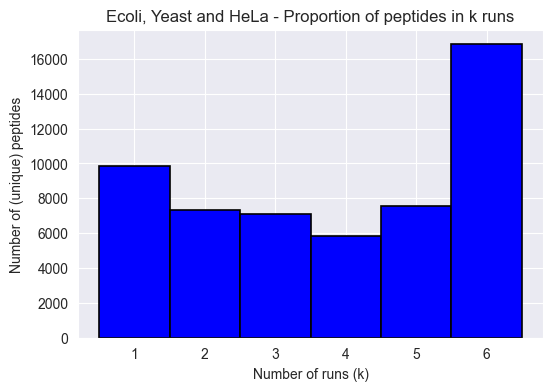

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(peptide_abundances, bins=range(1, np.max(peptide_abundances)+2), color='blue', edgecolor='black', linewidth=1.2, align='left')
ax.set_xticks(range(1, np.max(peptide_abundances)+1))
ax.set_title('Ecoli, Yeast and HeLa - Proportion of peptides in k runs')
ax.set_xlabel('Number of runs (k)')
ax.set_ylabel('Number of (unique) peptides')
ax.grid(True)
ax.set_axisbelow(True)

Let's add a column with species.

In [30]:
yeast_filter = ms2_species_data['Leading razor protein'].str.contains('YEAST')
ecoli_filter = ms2_species_data['Leading razor protein'].str.contains('ECOLI')
hela_filter = ~(yeast_filter | ecoli_filter)

ms2_species_data['Species'] = 'Unknown'
ms2_species_data.loc[yeast_filter, 'Species'] = 'Yeast'
ms2_species_data.loc[ecoli_filter, 'Species'] = 'Ecoli'
ms2_species_data.loc[hela_filter, 'Species'] = 'HeLa'

Let's look at the proportion of peptides in each species for the MS2 dataset with multiple species.

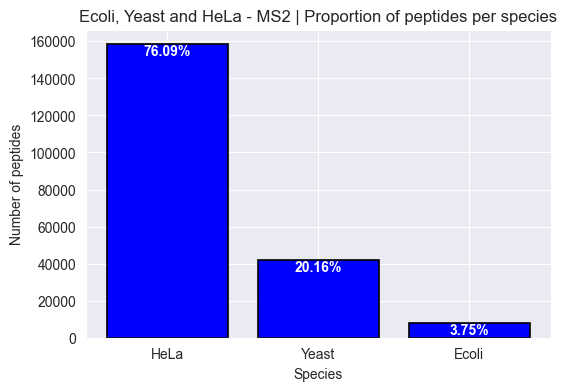

In [31]:
species = ms2_species_data['Species']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(species.value_counts().index, species.value_counts(), color='blue', edgecolor='black', linewidth=1.2)
ax.set_title('Ecoli, Yeast and HeLa - MS2 | Proportion of peptides per species')
ax.set_xlabel('Species')
ax.set_ylabel('Number of peptides')
ax.grid(True)
ax.set_axisbelow(True)

for i, v in enumerate(species.value_counts()):
    y = v - 4000
    text = f"{v / ms2_species_data.shape[0] * 100:.2f}%"
    ax.text(i, y, text, ha='center', va='center', fontweight='bold', color='white')

### Feature Extraction

Let's extract the features which the model takes as input.

It seems like the two types of datasets (MS1 and MS2) use a different name for 'Ion mobilility index length' / 'Ion mobility length'. Let's rename one of them to be consistent between the datasets.

In [32]:
ms1_hela_data = ms1_hela_data.copy()
ms1_hela_data.rename(columns={'Ion mobility index length': 'Ion mobility length'}, inplace=True)

In [33]:
features = ['Charge', 'Mass', 'm/z', 'Retention time','Retention length', 'Ion mobility index', 'Ion mobility length','Number of isotopic peaks']

Let's look at the distribution of the features.

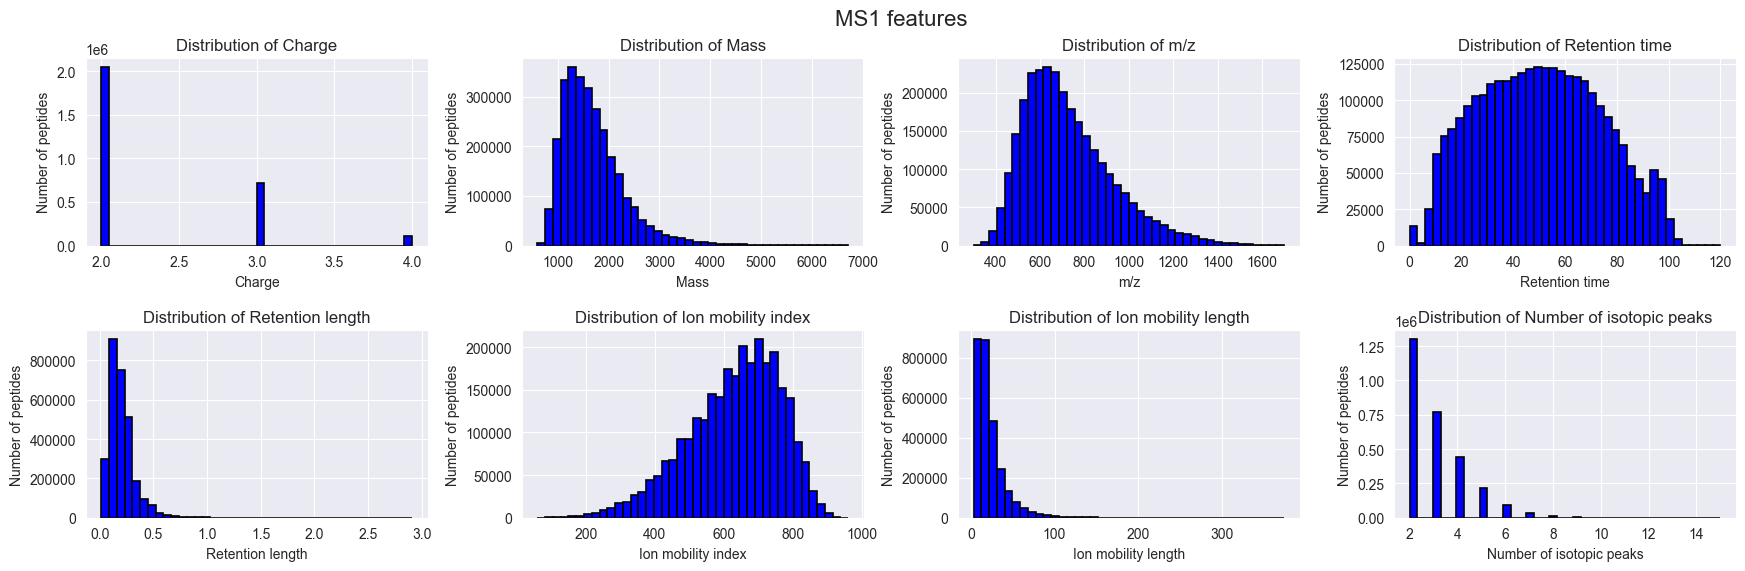

In [34]:
fig, axs = plt.subplots(figsize=(18, 6), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle('MS1 features', fontsize=16)

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    ax.hist(ms1_hela_data[feature], bins=40, color='blue', edgecolor='black', linewidth=1.2)
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of peptides')
    ax.set_title(f'Distribution of {feature}')
    ax.grid(True)
    ax.set_axisbelow(True)

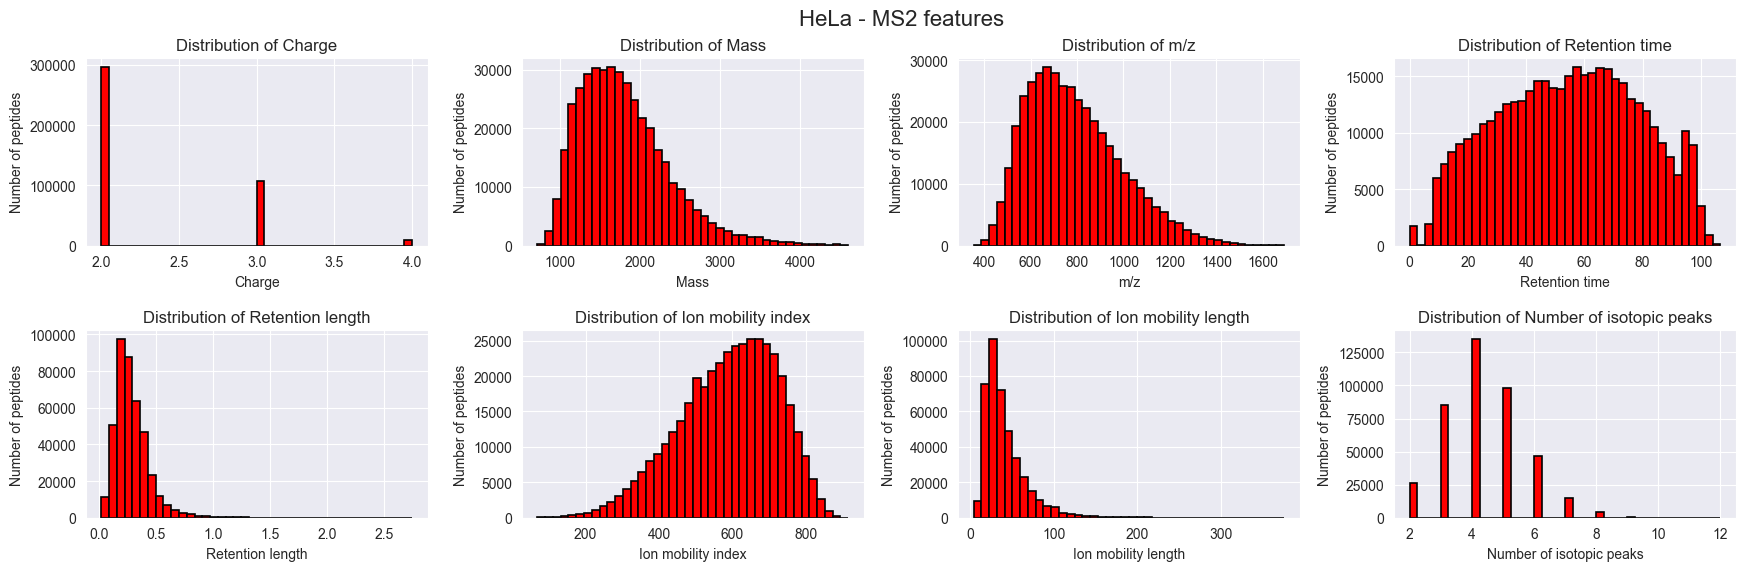

In [35]:
fig, axs = plt.subplots(figsize=(18, 6), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle('HeLa - MS2 features', fontsize=16)

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    ax.hist(ms2_hela_data[feature], bins=40, color='red', edgecolor='black', linewidth=1.2)
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of peptides')
    ax.set_title(f'Distribution of {feature}')
    ax.grid(True)
    ax.set_axisbelow(True)

Let's plot features by species as well for the species MS2 dataset.

/var/folders/vg/h0xwvtj55c173c6v1ny3h3t80000gn/T/ipykernel_88276/728060358.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(problematic_prototypes_df[feature], color='orange', label='Problematic', ax=ax)


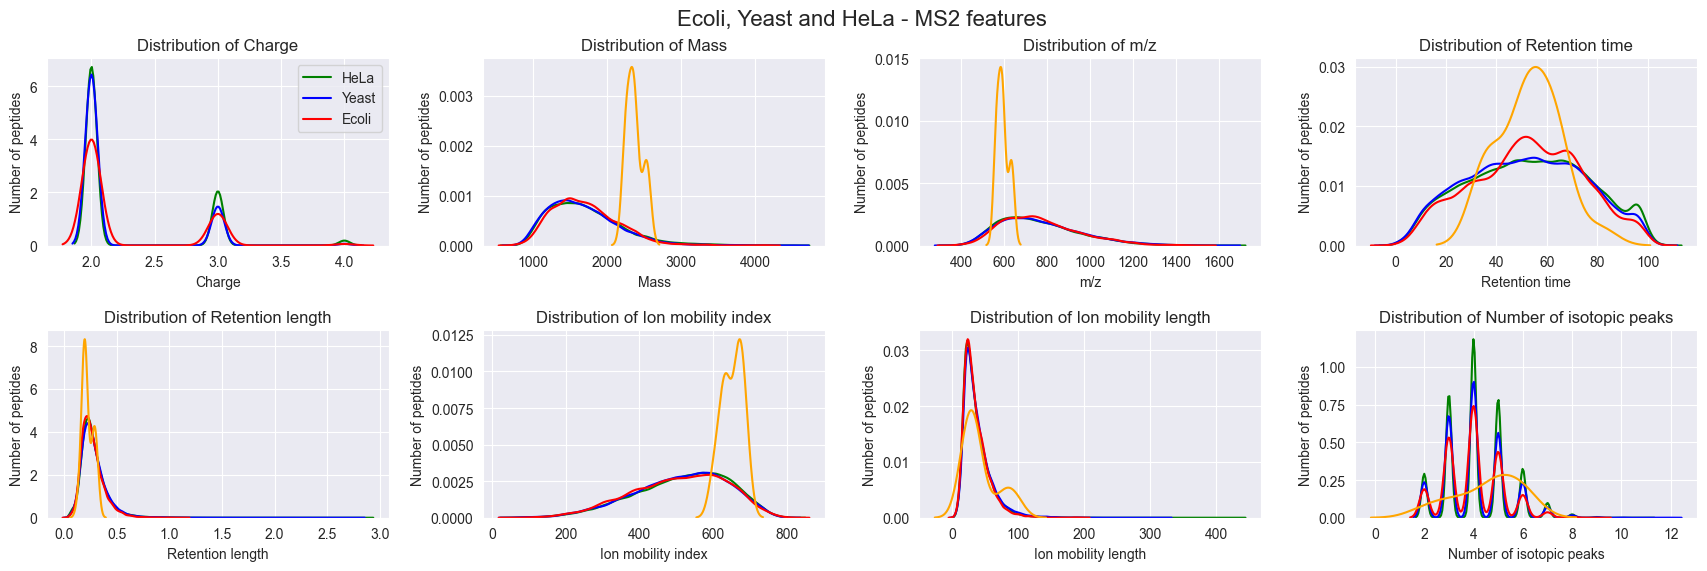

In [36]:
fig, axs = plt.subplots(figsize=(18, 6), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle('Ecoli, Yeast and HeLa - MS2 features', fontsize=16)

yeast_filter = ms2_species_data['Species'] == 'Yeast'
ecoli_filter = ms2_species_data['Species'] == 'Ecoli'
hela_filter = ms2_species_data['Species'] == 'HeLa'

problematic_sequences = [
            'LPYITFPEGSEEHTYLHAQR',
            'LSLTGGFSHHHATDDVEDAAPETK',
            'ILEVLQEPDNHHVSAEDLYK',
            'DVSLLHKPTTQISDFHVATR',
            'FGLPHADDVLGLPIGQHIVIK',
            'TLLEAIDAIEQPSRPTDKPLR']

# Extract problematic prototypes from ms2_species_data
problematic_prototypes_df = ms2_species_data[ms2_species_data['Sequence'].isin(problematic_sequences)]
problematic_prototypes_df = problematic_prototypes_df[problematic_prototypes_df['Charge'] == 4]

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    sns.kdeplot(ms2_species_data[hela_filter][feature], color='green', label='HeLa', ax=ax)
    sns.kdeplot(ms2_species_data[yeast_filter][feature], color='blue', label='Yeast', ax=ax)
    sns.kdeplot(ms2_species_data[ecoli_filter][feature], color='red', label='Ecoli', ax=ax)
    sns.kdeplot(problematic_prototypes_df[feature], color='orange', label='Problematic', ax=ax)
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of peptides')
    ax.set_title(f'Distribution of {feature}')
    ax.grid(True)
    ax.set_axisbelow(True)

axs[0][0].legend()

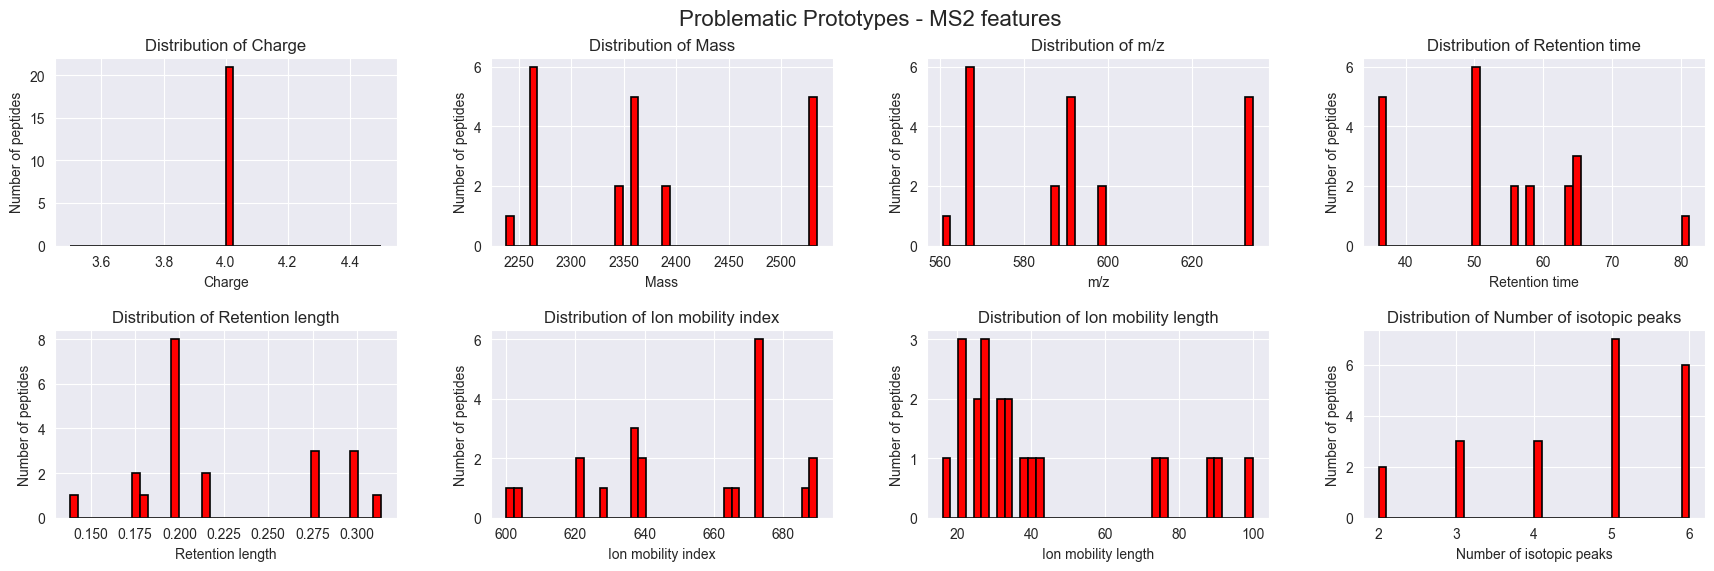

In [37]:
# Compare distribution of Yeast/Ecoli MS2 prototypes with problematic prototypes:
problematic_prototypes = [
            'Ecoli_LPYITFPEGSEEHTYLHAQR_4',
            'Yeast_LSLTGGFSHHHATDDVEDAAPETK_4',
            'Ecoli_ILEVLQEPDNHHVSAEDLYK_4',
            'Ecoli_DVSLLHKPTTQISDFHVATR_4',
            'Yeast_FGLPHADDVLGLPIGQHIVIK_4',
            'Yeast_TLLEAIDAIEQPSRPTDKPLR_4']

problematic_sequences = [
            'LPYITFPEGSEEHTYLHAQR',
            'LSLTGGFSHHHATDDVEDAAPETK',
            'ILEVLQEPDNHHVSAEDLYK',
            'DVSLLHKPTTQISDFHVATR',
            'FGLPHADDVLGLPIGQHIVIK',
            'TLLEAIDAIEQPSRPTDKPLR']

# Extract problematic prototypes from ms2_species_data
problematic_prototypes_df = ms2_species_data[ms2_species_data['Sequence'].isin(problematic_sequences)]
problematic_prototypes_df = problematic_prototypes_df[problematic_prototypes_df['Charge'] == 4]

fig, axs = plt.subplots(figsize=(18, 6), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle('Problematic Prototypes - MS2 features', fontsize=16)

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    ax.hist(problematic_prototypes_df[feature], bins=40, color='red', edgecolor='black', linewidth=1.2)
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of peptides')
    ax.set_title(f'Distribution of {feature}')
    ax.grid(True)
    ax.set_axisbelow(True)

The individual features for each dataset appear to be similiarly distributed between datasets.

In [38]:
ms1_hela_features = ms1_hela_data[features]
ms2_hela_features = ms2_hela_data[features]

ms2_hela_features = ms2_species_data[features]

## PIPP model

### Computing the Embeddings

Let's load the model and compute the embeddings.

In [39]:
model = pipp.Peptideprotonet.load(PRETRAINED_MODEL_PATH)

In [40]:
ms1_hela_embeddings = model.get_latent_representations(ms1_hela_features)

In [41]:
ms2_hela_embeddings = model.get_latent_representations(ms2_hela_features)

In [42]:
ms2_species_embeddings = model.get_latent_representations(ms2_hela_features)

In [43]:
ms1_embedding_means = np.mean(ms1_hela_embeddings, axis=0)

ms1_hela_embeddings -= ms1_embedding_means
ms2_hela_embeddings -= ms1_embedding_means
ms2_species_embeddings -= ms1_embedding_means

In [44]:
#ms1_hela_embeddings -= np.mean(ms1_hela_embeddings, axis=0)
#ms2_hela_embeddings -= np.mean(ms2_hela_embeddings, axis=0)
#ms2_species_embeddings -= np.mean(ms2_species_embeddings, axis=0)

#### Ecoli, Yeast and HeLa - MS2 UMAP

Let's look at the embedding space.
We'll look at a subset of peptides due to memory limitations.

In [45]:
N = 50_000
random_indices = np.random.choice(range(len(ms2_species_embeddings)), size=N, replace=False)

Let's also add some "random" peptides to ensure all possible runs of at least a few peptides are included.

In [46]:
high_coverage_peptides_to_include = [
    '_(ac)AAAAAAAAAAGAAGGR_2',
    '_GLGAAEFGGAAGNVEAPGETFAQR_2',
    '_GLGLSPDLVVCR_2',
    '_SSLDNIEMAYAR_2',
    '_GLGHQVATDALVAMEK_3',
    '_SSMQIDNAPTPHNTPASVLNPSYLK_3',
    '_GLESLPPLRPQQNPVLPVAGER_3',
    '_GLELIASENFCSR_2',
    '_SSLAMIGHDGPNDMK_2',
]

low_coverage_peptides_to_include = [
    '_FTDEDEQGLR_2',
    '_SLPVPQLVPETEDEKK_2',
    '_EAEPDLLAVLR_2',
    '_SLPQTLILNPIR_2',
    '_DETGELSSADEK_2',
    '_GYLTDLNSMIPTHGGDINDIK_3',
    '_GYNPGLLVHPDLAYLQAEGGGDR_3',
    '_EVMQEVAQLSQFDEELYK_3',
    '_VPPATAFEGHMLLSGLEPFR_3',
    '_DEMLGLVPMR_2',
]

peptides_to_include = high_coverage_peptides_to_include + low_coverage_peptides_to_include

custom_indices = [ms2_species_data.index[ms2_species_data['PrecursorID'] == peptide].tolist() for peptide in peptides_to_include]
custom_indices = [peptide for peptide_runs in custom_indices for peptide in peptide_runs]
custom_indices = [ms2_species_data.index.get_loc(i) for i in custom_indices]

# print(peptides_abundances)

In [47]:
indices = np.unique(np.concatenate((random_indices, custom_indices)))

In [48]:
ms2_subset_data = ms2_species_data.iloc[indices]
ms2_subset_embeddings = ms2_species_embeddings[indices]

Let's compute the UMAP for plotting.

In [49]:
reducer = umap.UMAP(metric = 'cosine')
umap_embedding = reducer.fit_transform(ms2_subset_embeddings)

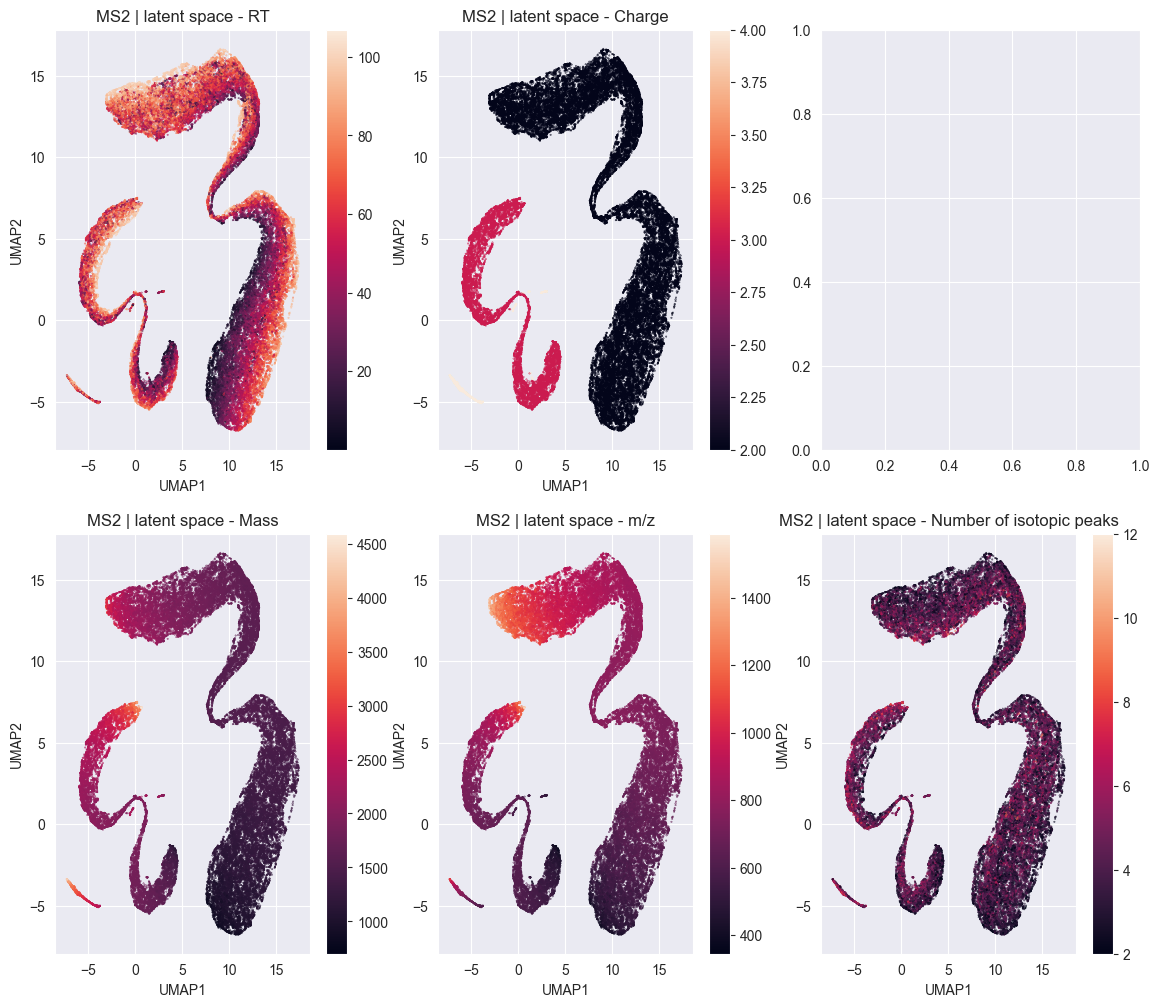

In [50]:
fig, axs = plt.subplots(figsize=(14, 12), ncols=3, nrows=2)

ax = axs[0][0]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_subset_data['Retention time'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - RT')
fig.colorbar(sp)

ax = axs[0][1]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_subset_data['Charge'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Charge')
fig.colorbar(sp)

ax = axs[1][0]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_subset_data['Mass'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Mass')
fig.colorbar(sp)

ax = axs[1][1]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_subset_data['m/z'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - m/z')
fig.colorbar(sp)

ax = axs[1][2]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_subset_data['Number of isotopic peaks'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Number of isotopic peaks')
fig.colorbar(sp)

Let's plot the latent space for each specie. We'll scale based on proportion of peptides in each specie.

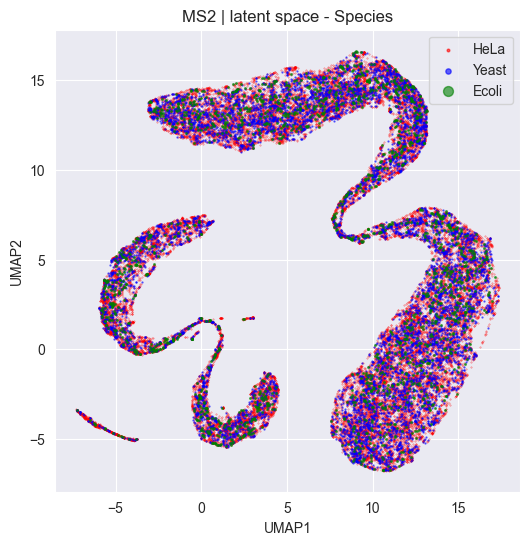

In [51]:
colors = ['red', 'blue', 'green']
color_map = {species: color for species, color in zip(ms2_subset_data['Species'].unique(), colors)}
species_size = {'HeLa': .1, 'Yeast': .4, 'Ecoli': 1.4}

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Species')

for species, color in color_map.items():
    umap1 = umap_embedding[ms2_subset_data['Species'] == species][:,0]
    umap2 = umap_embedding[ms2_subset_data['Species'] == species][:,1]
    ax.scatter(umap1, umap2, c=color, s=species_size[species], label=species, alpha=0.6)

ax.legend(markerscale=6)

Let's also plot the latent space of the MS2 data together with some low coverage and high coverage peptides.

Text(0.5, 1.0, 'low coverage peptides')

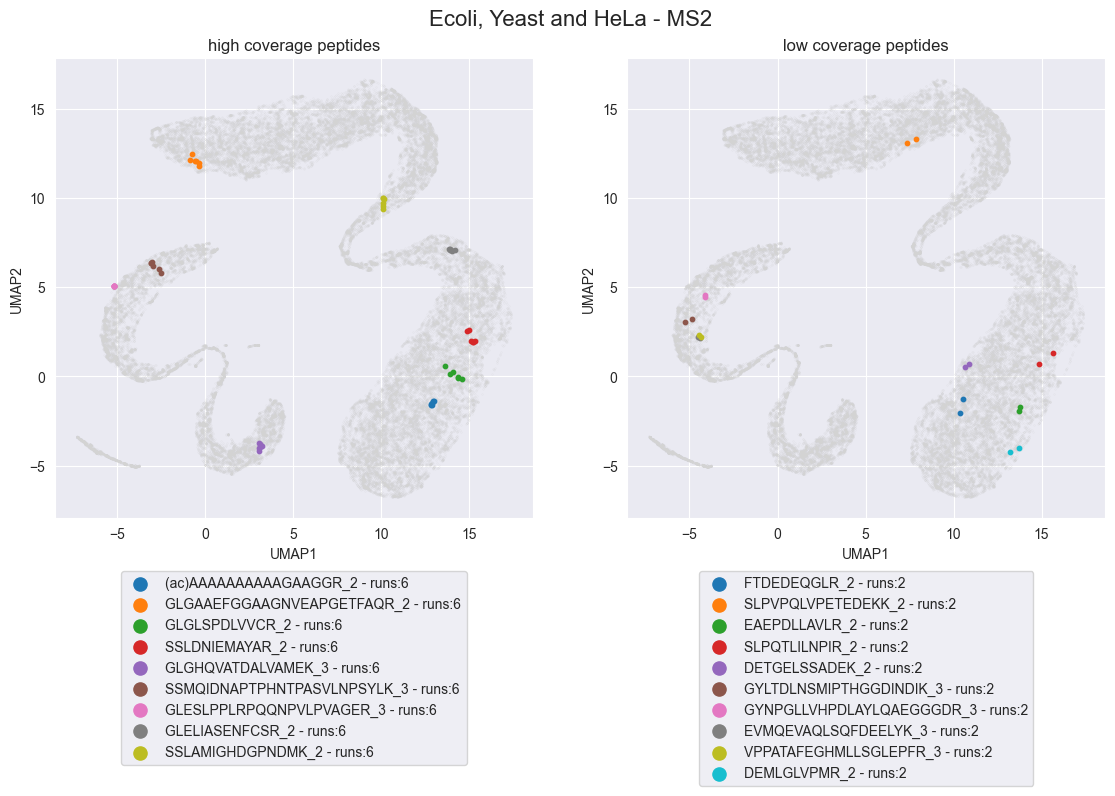

In [52]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)
fig.tight_layout(pad=4.0)

fig.suptitle('Ecoli, Yeast and HeLa - MS2', fontsize=16)

# high coverage peptides
ax = axs[0]
ax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color='lightgrey')

for i, peptide in enumerate(high_coverage_peptides_to_include):
    peptide_ref_indices = np.where(ms2_subset_data['PrecursorID'] == peptide)
    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")

ax.legend(markerscale=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('high coverage peptides')

# low coverage peptides
ax = axs[1]
ax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color='lightgrey')

for i, peptide in enumerate(low_coverage_peptides_to_include):
    peptide_ref_indices = np.where(ms2_subset_data['PrecursorID'] == peptide)
    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")

ax.legend(markerscale=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('low coverage peptides')

Let's also plot the latent representation of both MS2 datasets.

In [53]:
ms2_all_data = pd.concat([ms2_hela_data, ms2_species_data], ignore_index=True)

In [54]:
latent = model.get_latent_representations(ms2_all_data[features])

In [55]:
print(f"Number of prototypes: {ms2_all_data['PrecursorID'].nunique()}")

Number of prototypes: 86678


In [56]:
N = 50_000
M = N // 2

hela_random_indices = np.random.choice(range(len(ms2_hela_data)), size=M, replace=False)
species_random_indices = np.random.choice(range(len(ms2_species_data)), size=M, replace=False)

random_indices = np.concatenate((hela_random_indices, species_random_indices + len(ms2_hela_data)))

ms2_subset_embeddings = latent[random_indices]
ms2_subset_data = ms2_all_data.iloc[random_indices]

In [57]:
reducer = umap.UMAP(metric = 'cosine')
umap_embedding = reducer.fit_transform(ms2_subset_embeddings)

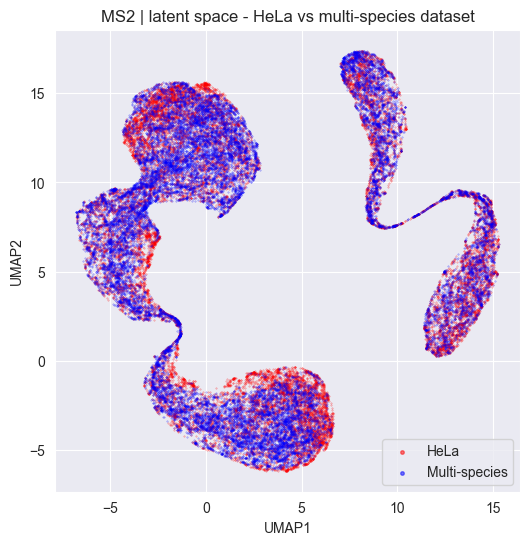

In [58]:
colors = ['red', 'blue']
color_map = {dataset: color for dataset, color in zip(ms2_subset_data['Dataset'].unique(), colors)}

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - HeLa vs multi-species dataset')

for dataset, color in color_map.items():
    umap1 = umap_embedding[ms2_subset_data['Dataset'] == dataset][:,0]
    umap2 = umap_embedding[ms2_subset_data['Dataset'] == dataset][:,1]
    ax.scatter(umap1, umap2, c=color, s=.1, label=dataset, alpha=.5)

ax.legend(markerscale=8)

## False Discovery Rates for MS1 data

Let's compute the false discovery rate (FDR).

Let's first extract the HeLa MS2 entries from the HeLa MS1 data.

In [59]:
ms1_hela_only_locs = ms1_hela_data.index.difference(ms2_hela_data.index)
ms1_hela_only_ilocs = ms1_hela_data.index.get_indexer(ms1_hela_only_locs)

In [60]:
ms1_hela_only = ms1_hela_data.iloc[ms1_hela_only_ilocs]

Let's append the species to the precursors.

In [61]:
species_precursor_id = ms2_all_data['Species'].astype(str).str.cat(ms2_all_data['PrecursorID'].astype(str), sep='')
ms2_all_data['PrecursorID'] = species_precursor_id

### This is the main function to test the False Discovery Rate of PIPP with ESM-2 integration with multiple model configurations and parameters.
 - **k_neighbours**: Specifies how many closest neighbour prototypes are computed for each query precursor. We are only interested in the single closest neighbour prototype. But according to the documentation of pynndescent, the accuracy is higher if more neighbours are computed.

  - **esm2_model**: Specifies the ESM-2 model. The following models are available and are downloaded in the first use.
    - "esm2_t6_8M_UR50D": 6 layers, 8 million parameters, 320-dim embedding
    - "esm2_t12_35M_UR50D": 12 layers, 35 million parameters, 480-dim embedding
    - "esm2_t30_150M_UR50D": 30 layers, 150 million parameters, 640-dim embedding
    - "esm2_t33_650M_UR50D": 33 layers, 650 million parameters, 1280-dim embedding
    - "esm2_t36_3B_UR50D": : 36 layers, 3 billion parameters, 2560-dim embedding, 6GB size
    - "esm2_t48_15B_UR50D": 48 layers, 15 billion parameters, 5120-dim embedding, 30GB size

 - **n_representation_layer**: Specifies the ESM-2 layer from which the representations should be taken

 - **use_precomputed_esm_embeddings**: Specifies whether to use ESM-2 embeddings that have already been computed. If True, then the location needs to be specified below.

 - **esm_embedding_path**: Specifies the relative path to the precomputed ESM-2 embeddings.
    - 'example_data/esm2_t33_650M_UR50D_embeddings_6.npy'
    
 - **output_file_path**: Specifies the output file path for False Discovery Rate results.

 - **generate_visualizations**: Specifies whether to compute visualizations of the process. Computation time is increased substantially. Visualizations include:
 
    - Scree plot and Cumulative Explained Variance plot of Principal Component Analysis of ESM-2 embedding
    - UMAP of concatenated MS1+ESM embeddings
    - UMAP of relative representations  

 - **n_anchor_list**: Specifies the numbers of anchors for the relative representation. For each entry in the list, a whole propagation run will be performed.

 - **n_pc_list**: Specifies the numbers of principal components that the ESM-2 embedding ist reduced to. For each entry in the list, a whole propagation run will be performed.

 - **number_of_test_runs**: Specifies the number of times the propagation function will be run for each combination of anchor numbers and principal component numbers.

 - **conduct_neighbour_experiment**: Specifies whether to create the following output files that are required to conduct the species separation experiment.
    - 'example_data/final_false_list.pkl'
    - 'example_data/final_true_list.pkl'    


Anchors:  5 , PCs:  1
computing prototypes...
Computing relative representations...


/Users/lucasronchetti/PycharmProjects/thesis_project/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


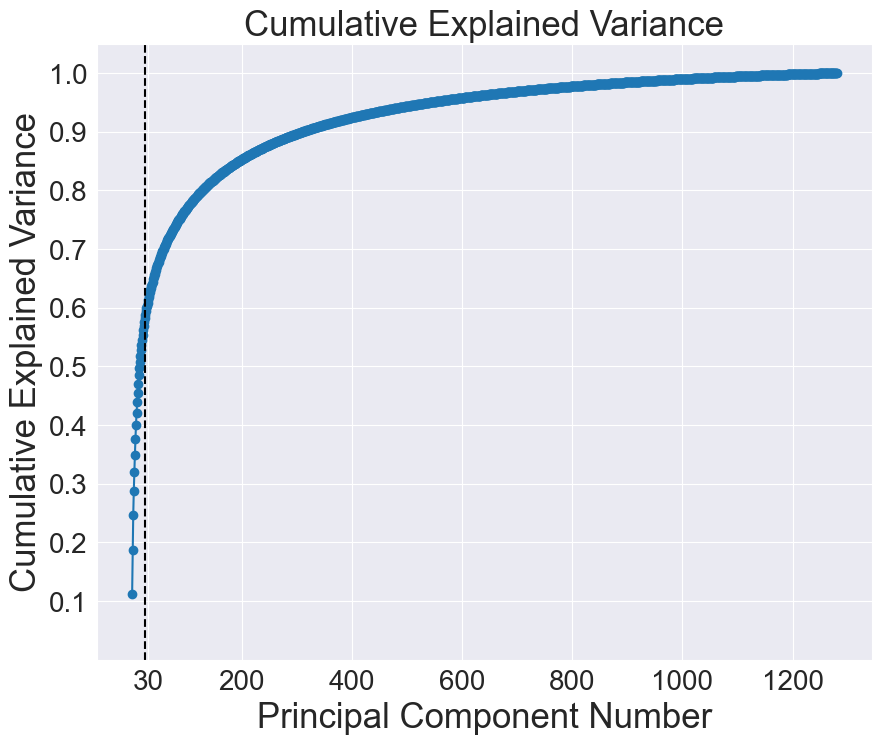

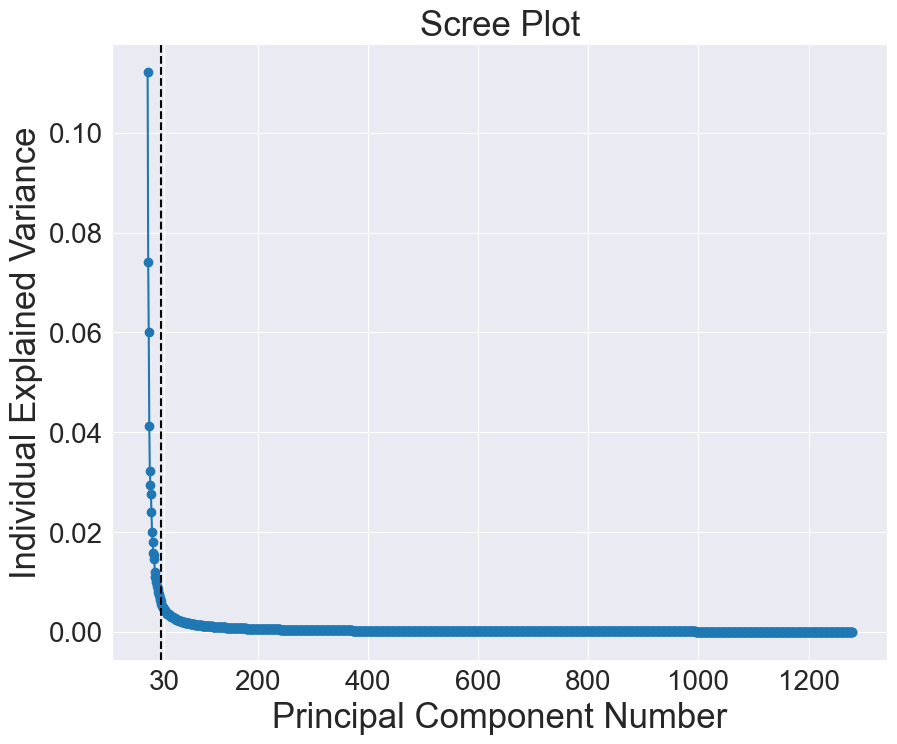

KeyboardInterrupt: 

In [72]:
# Number of prototype neighbours to compute for each precursor
k_neighbours = 15

# ESM-2 model
esm2_model = "esm2_t33_650M_UR50D"

# ESM-2 layer from which the representations should be taken
n_representation_layer = 6

# Whether to use precomputed ESM-2 embeddings
use_precomputed_esm_embeddings = True

# Relative path to the precomputed ESM-2 embeddings
esm_embedding_path = 'example_data/esm2_t33_650M_UR50D_embeddings_6.npy'

# Output file path for False Discovery Rate results.
output_file_path = 'example_data/fdr_multi_test_result_6_6.csv'

# Whether to compute visualizations of the process.
generate_visualizations = True

# Numbers of anchors for the relative representation.
n_anchor_list = [5, 10, 50, 100, 200, 300] # 5, 10, 50, 100, 200, 300, 400, 700, 1000

# Numbers of principal components that the ESM-2 embedding is reduced to.
n_pc_list = [1, 2, 3, 5, 10, 20, 30] # 1, 2, 3, 5, 10, 15, 20, 30, 40, 50

# Number of times the propagation function will be run.
number_of_test_runs = 5

conduct_neighbour_experiment = False

results_df = pd.DataFrame(columns=['n_anchors',
                                   'n_pcs',
                                   'proportion_ft',
                                   'proportion_ft_conf1',
                                   'proportion_unique_t',
                                   'fdr_conf1'])

for _ in range(number_of_test_runs): # e.g. 100 or 1000
    
    for n_anchor in n_anchor_list:
        
        random_state = np.random.RandomState()
        anchors_idx = random_state.choice(71992, n_anchor, replace=False)
        
        for n_pc in n_pc_list:
            if n_pc == 0:
                use_concatenated_embeddings = False
            else:
                use_concatenated_embeddings = True
            
            print('Anchors: ', n_anchor, ', PCs: ', n_pc)
            identifications, confidence = model.propagate(
                ms1_hela_only,
                ms2_all_data,
                k_neighbours=k_neighbours,
                use_anchors=True,
                esm2_model=esm2_model,
                n_representation_layer=n_representation_layer,
                n_anchors=n_anchor,
                n_principal_components=n_pc,
                use_precomputed_esm_embeddings=use_precomputed_esm_embeddings,
                esm_embedding_path=esm_embedding_path,
                generate_visualizations=generate_visualizations,conduct_neighbour_experiment=conduct_neighbour_experiment,
                use_preselected_anchors=True,
                anchors_idx=anchors_idx,
                use_concatenated_embeddings=use_concatenated_embeddings)
            
            # disable warnings for the following assignments
            pd.options.mode.chained_assignment = None  # default='warn'
            
            ms1_hela_only['pred_ident'] = identifications
            ms1_hela_only['pred_confidence'] = confidence
            
            hela_filter = np.array([identity.startswith('HeLa') for identity in identifications])
            yeast_filter = np.array([identity.startswith('Yeast') for identity in identifications])
            ecoli_filter = np.array([identity.startswith('Ecoli') for identity in identifications])
            
            ms1_hela_only['pred_HeLa'] = hela_filter
            ms1_hela_only['pred_Yeast'] = yeast_filter
            ms1_hela_only['pred_Ecoli'] = ecoli_filter
            
            ms1_hela_only_max_conf = ms1_hela_only[ms1_hela_only['pred_confidence'] == 1.0]
            ms1_hela_only_max_conf_false = ms1_hela_only_max_conf[ms1_hela_only_max_conf['pred_HeLa'] == False]
            ms1_hela_only_false = ms1_hela_only[ms1_hela_only['pred_HeLa'] == False]
            ms1_hela_only_false = ms1_hela_only_false.drop(['pred_HeLa', 'pred_Ecoli', 'pred_Yeast', 'pred_ident', 'pred_confidence', 'Dataset'], axis=1)
            
            # FDR at confidence = 1
            identified_counts_conf1 = [np.sum(confidence[species_filter] == 1.0) for species_filter in [yeast_filter, ecoli_filter]]
            
            proportion_ft = len(ms1_hela_only_false) / 2575850 * 100
            proportion_ft_conf1 = len(ms1_hela_only_max_conf_false) / 2575850 * 100
            unique_count = ms1_hela_only['pred_ident'].nunique()
            proportion_unique_t = unique_count / 86705 * 100 
            fdr_conf1 = np.sum(identified_counts_conf1) / np.sum(confidence == 1.0)
            
            # Append the list of results to the DataFrame
            results_df.loc[len(results_df.index)] = [n_anchor, n_pc, proportion_ft, proportion_ft_conf1, proportion_unique_t, fdr_conf1] 
            
            results_df.to_csv(output_file_path, index=False)


In [ ]:
df = pd.read_csv("example_data/fdr_multi_test_result.csv")

'''
Specify here which domain to compare:
- "fdr_conf1": False Discovery Rate at Confidence Level 1
- "proportion_ft": Proportion of False Transfers to All Transfers
'''
domain_to_compare = 'fdr_conf1'
# x-axis: n_anchors, y-axis: fdr_conf1, group by: n_pc
unique_n_pc = df['n_pcs'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_pc)))

plt.figure(figsize=(14, 10))
plt.axhline(y=.01, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.05, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.1, color='black', linestyle='dashdot', alpha=0.6)
# Specify the upper limit of FDR to view:
plt.ylim(0, 1 if domain_to_compare == 'fdr_conf1' else 100)

# Plot each line separately for each unique value in 'n_pc'
for i, n_pc in enumerate(unique_n_pc):
    subset_df = df[df['n_pcs'] == n_pc]
    mean_values = subset_df.groupby('n_anchors')[domain_to_compare].mean()
    plt.plot(mean_values.index, mean_values.values, marker='o', linestyle='--',
             label=f'PCs: {int(n_pc)}' if n_pc > 0 else "Without ESM", color=colors[i])

plt.xlabel('Number of Anchors')
plt.xticks([5, 10, 50, 100, 200, 300])
plt.ylabel(
    'FDR at Confidence Level 1' if domain_to_compare == 'fdr_conf1' else 'Percentage of False Transfers to All Transfers')
plt.title(
    'FDR at Confidence Level 1 for Number of Anchors grouped by PCs' if domain_to_compare == 'fdr_conf1' else 'Percentage of False Transfers to All Transfers for Number of Anchors grouped by PCs')
plt.legend()

plt.show()
# x-axis: n_pc, y-axis: fdr_conf1, group by: n_anchors
unique_n_anchors = df['n_anchors'].unique()

colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_anchors)))

plt.figure(figsize=(14, 10))
plt.axhline(y=.01, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.05, color='black', linestyle='dashdot', alpha=0.6)
plt.axhline(y=.1, color='black', linestyle='dashdot', alpha=0.6)
# Specify the upper limit of FDR to view:
plt.ylim(0, 1 if domain_to_compare == 'fdr_conf1' else 100)

# Plot each line separately for each unique value in 'n_pc'
for i, n_anchor in enumerate(unique_n_anchors):
    subset_df = df[df['n_anchors'] == n_anchor]
    mean_values = subset_df.groupby('n_pcs')[domain_to_compare].mean()
    plt.plot(mean_values.index, mean_values.values, marker='o', linestyle='--',
             label=f'Anchors: {int(n_anchor)}', color=colors[i])

plt.xlabel('Number of PCs')
plt.xticks([0, 1, 2, 3, 5, 10, 20], ['Without ESM', 1, 2, 3, 5, 10, 20])  # ,2,5,10
plt.ylabel(
    'FDR at Confidence Level 1' if domain_to_compare == 'fdr_conf1' else 'Percentage of False Transfers to All Transfers')
plt.title(
    'FDR at Confidence Level 1 for Number of PCs grouped by Anchors' if domain_to_compare == 'fdr_conf1' else 'Percentage of False Transfers to All Transfers for Number of PCs grouped by Anchors')
plt.legend()

plt.show()
# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(x=df['n_anchors'], y=df['n_pcs'], z=df['fdr_conf1'], mode='markers')])
fig.update_layout(scene=dict(aspectmode='cube',
                             xaxis=dict(title='Number of Anchors'),
                             yaxis=dict(title='Number of PCs'),
                             zaxis=dict(title='FDR at Confidence Level 1')),
                  title='3D Scatter Plot',
                  width=800,
                  height=800)
fig.show()
# Create 3D surface plot
df_agg = df.groupby(['n_anchors', 'n_pcs']).mean().reset_index()

# Reshape the DataFrame into a grid
x_vals = sorted(df_agg['n_anchors'].unique())
y_vals = sorted(df_agg['n_pcs'].unique())
z_vals = df_agg.pivot(index='n_anchors', columns='n_pcs', values='fdr_conf1').values

# Create the surface plot
fig = go.Figure(data=[go.Surface(z=z_vals, x=x_vals, y=y_vals)])

# Update layout with axis labels and title
fig.update_layout(scene=dict(xaxis_title='Number of Anchors',
                             yaxis_title='Number of PCs',
                             zaxis_title='FDR at Confidence Level 1'),
                  title='3D Surface Plot',
                  width=800,
                  height=800)

fig.show()